
Fit für 1s biggest 07:50:08
A1:      10.9266 ± 0.0248264
f:       0.0107159 ± 8.3561e-07
phi1:    -0.258575 ± 0.00229396
A2:      0.471079 ± 0.0249301
phi2:    7.56795 ± 0.0529678
Offset:  48.1928 ± 0.0176428
Periode: 93.3189


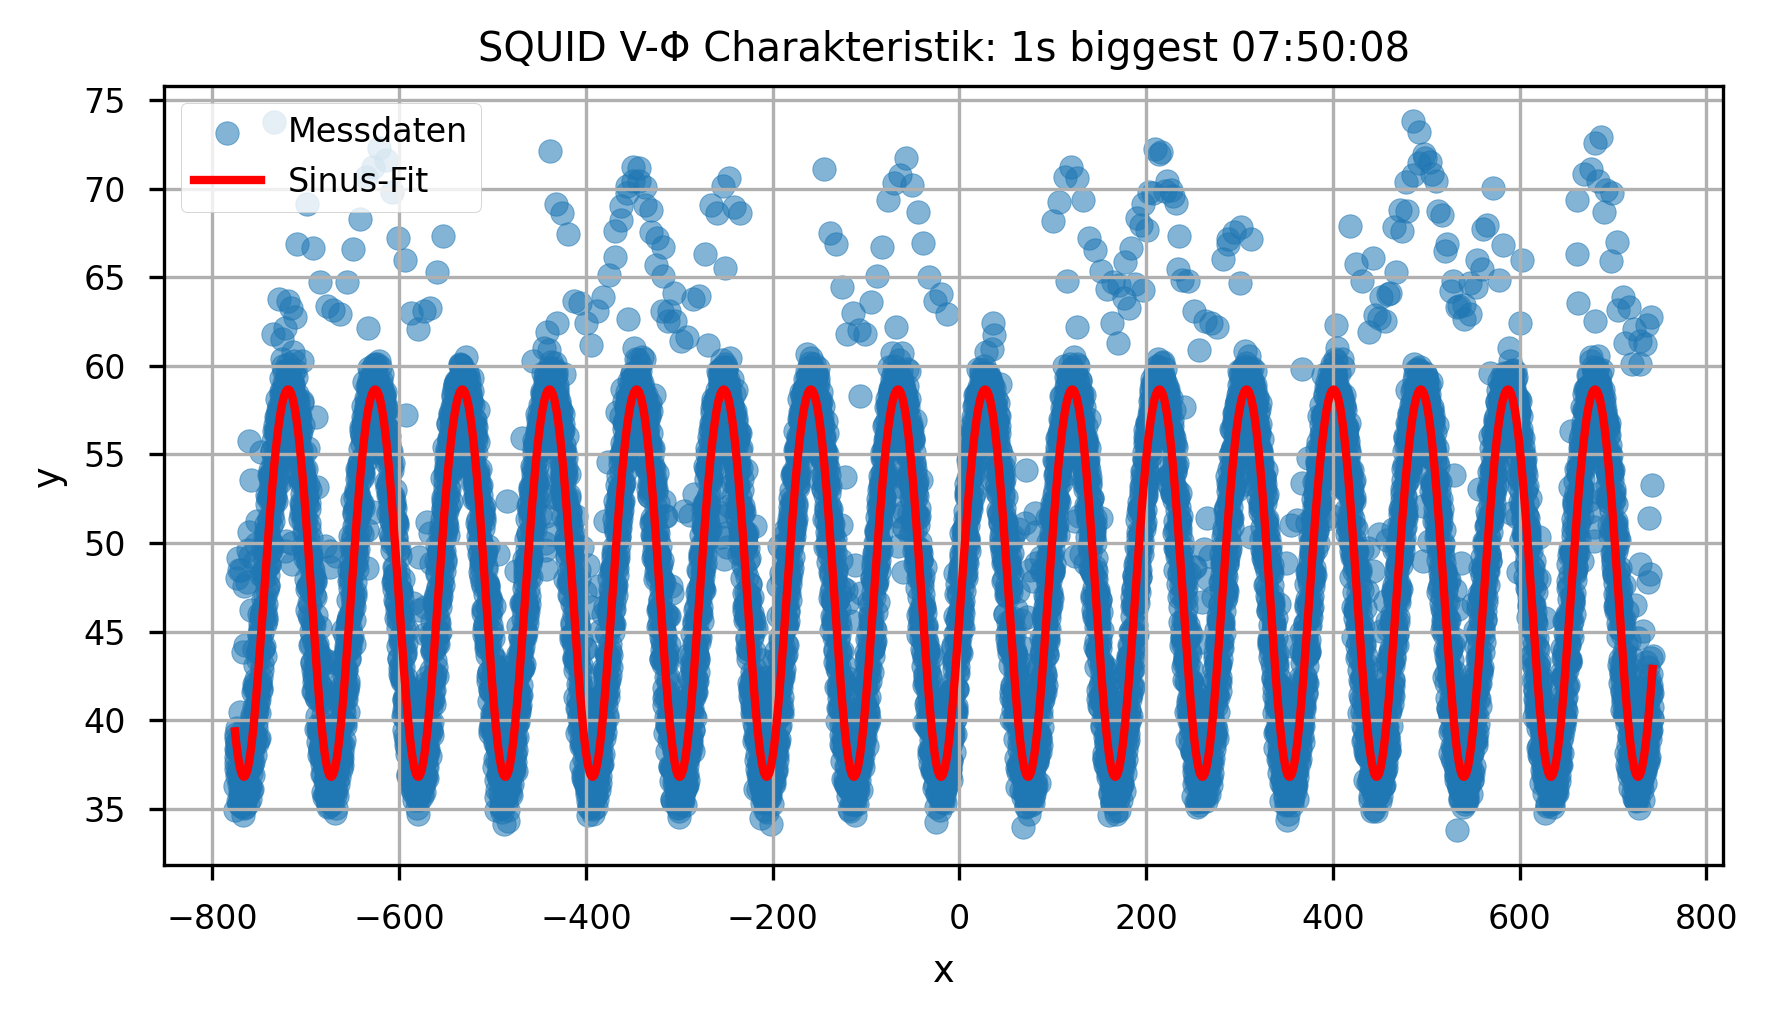


Fit für 1s biggest 07:49:48
A1:      11.1441 ± 0.0263483
f:       0.0107142 ± 8.70096e-07
phi1:    -0.254097 ± 0.00238776
A2:      0.496238 ± 0.0264744
phi2:    7.59683 ± 0.0533506
Offset:  48.2526 ± 0.0187278
Periode: 93.3339


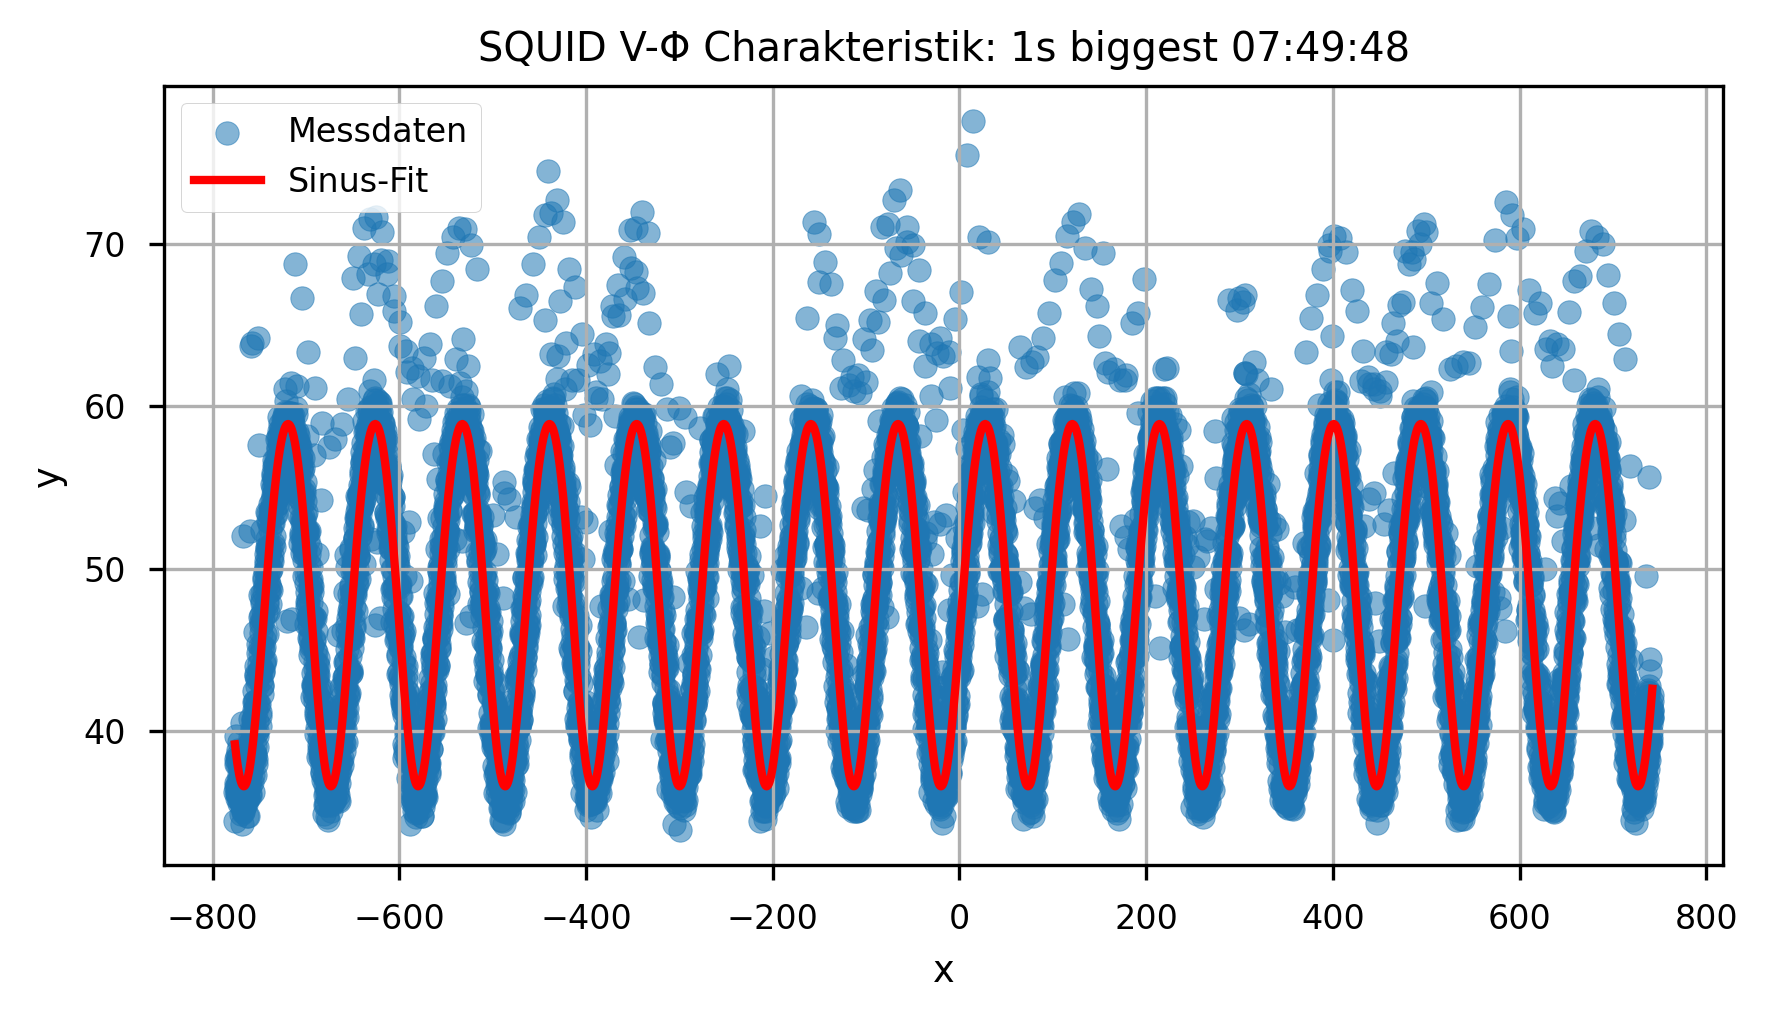


Fit für 0.5s biggest 07:48:07
A1:      10.8945 ± 0.0736901
f:       0.0107152 ± 2.50118e-06
phi1:    -0.243174 ± 0.00680723
A2:      -0.50924 ± 0.0740564
phi2:    4.38494 ± 0.144963
Offset:  48.9136 ± 0.052306
Periode: 93.3257


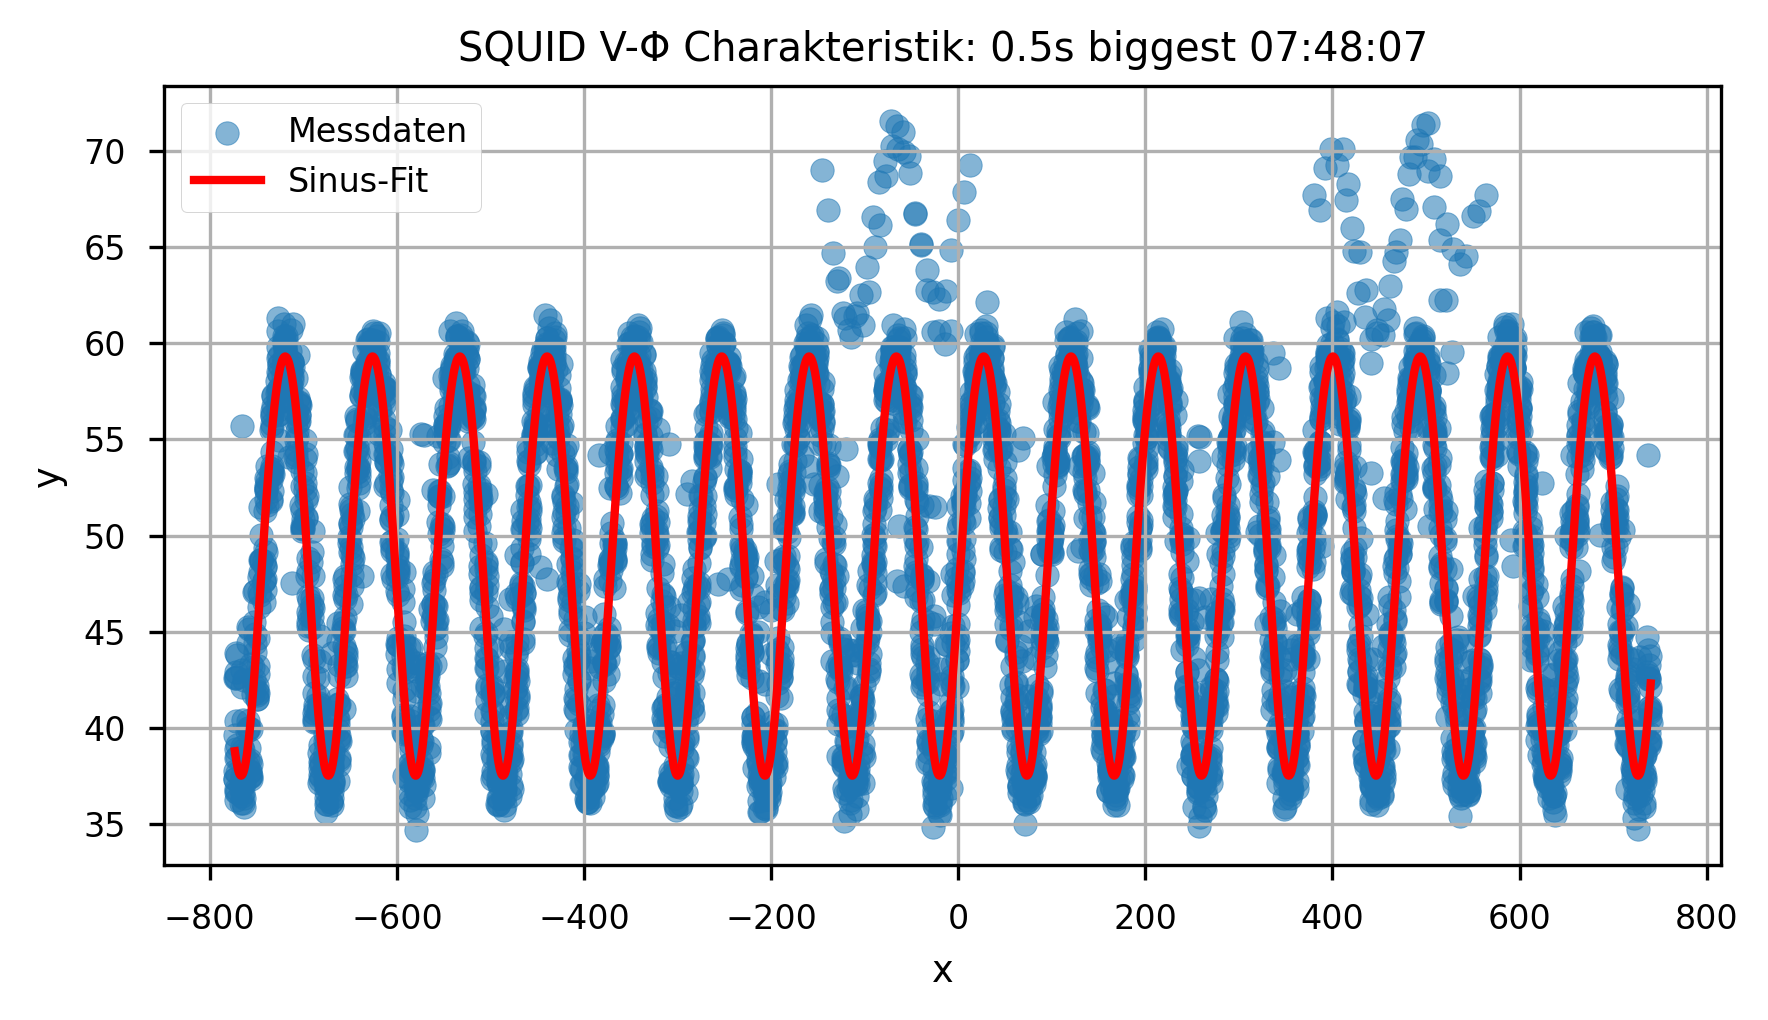


Fit für 0.5s biggest 07:48:04
A1:      10.6734 ± 0.0701789
f:       0.0107132 ± 2.42006e-06
phi1:    -0.246985 ± 0.00663102
A2:      0.57404 ± 0.0707185
phi2:    7.5675 ± 0.122324
Offset:  48.9485 ± 0.0498505
Periode: 93.3425


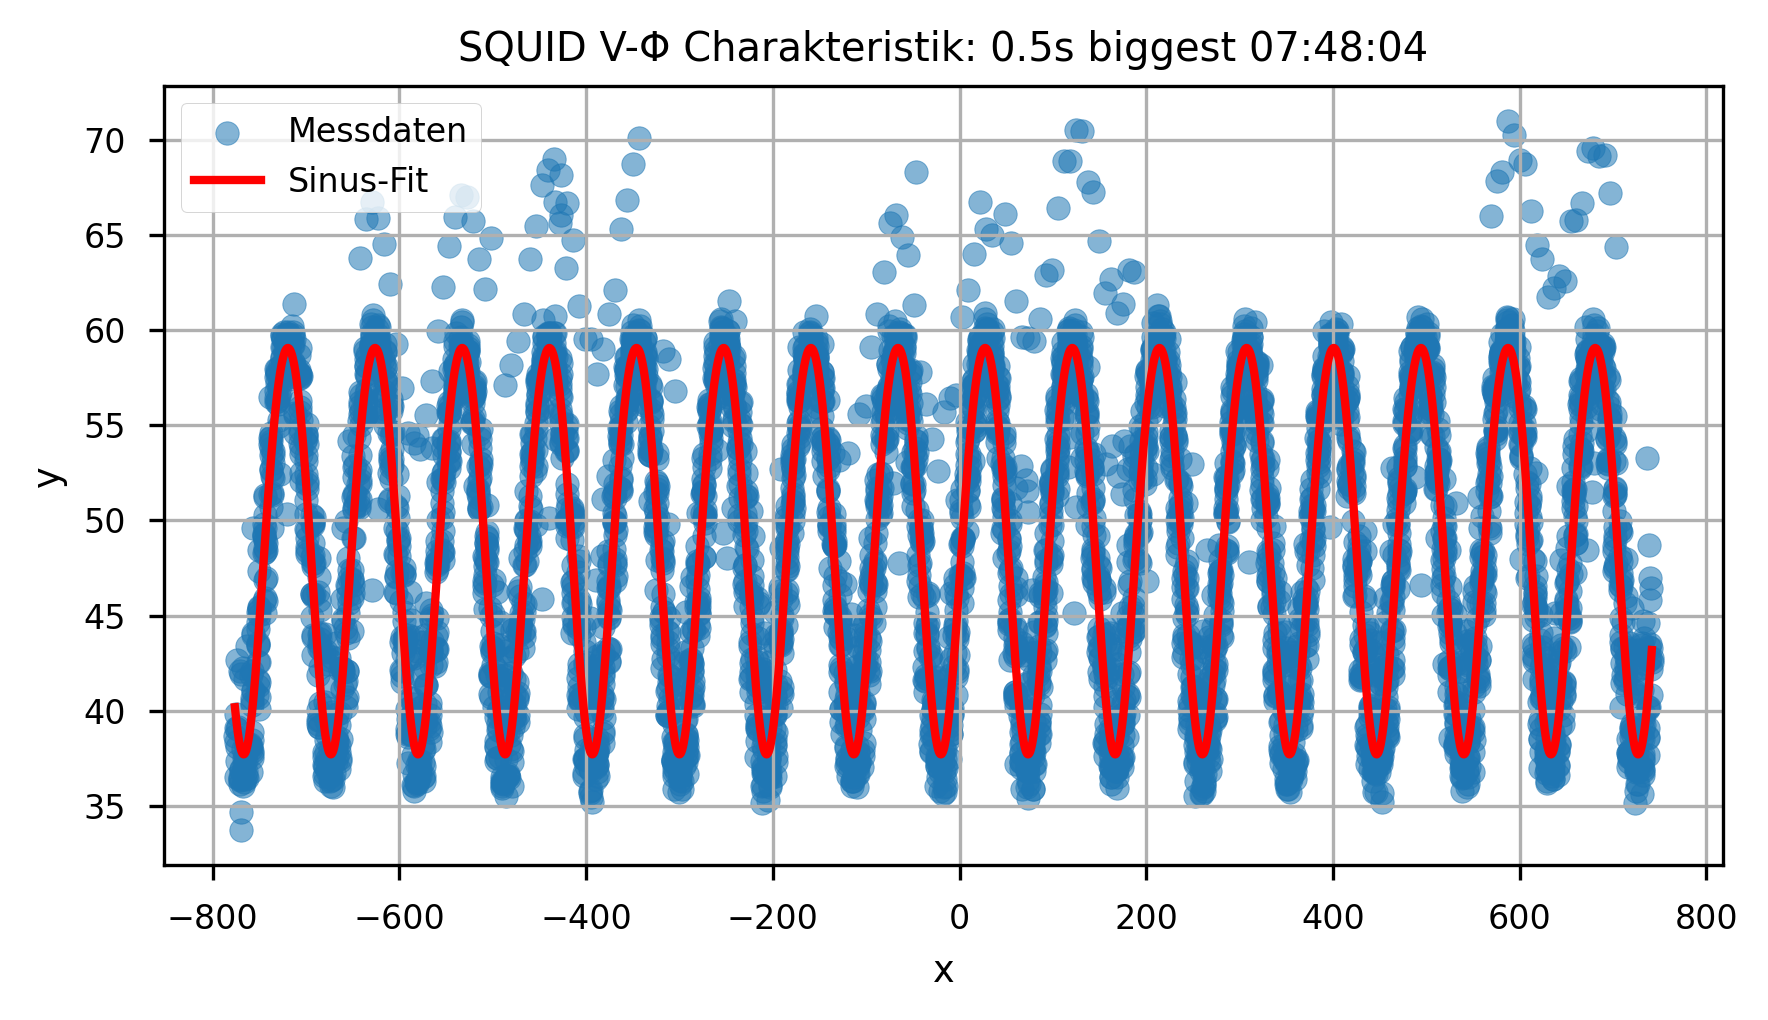


Fit für FLL 1
A1:      5.48963 ± 0.0188188
f:       0.0107166 ± 1.88082e-06
phi1:    0.926812 ± 0.00344906
A2:      -0.281899 ± 0.0188662
phi2:    0.410506 ± 0.0671017
Offset:  102.516 ± 0.0133496
Periode: 93.3129


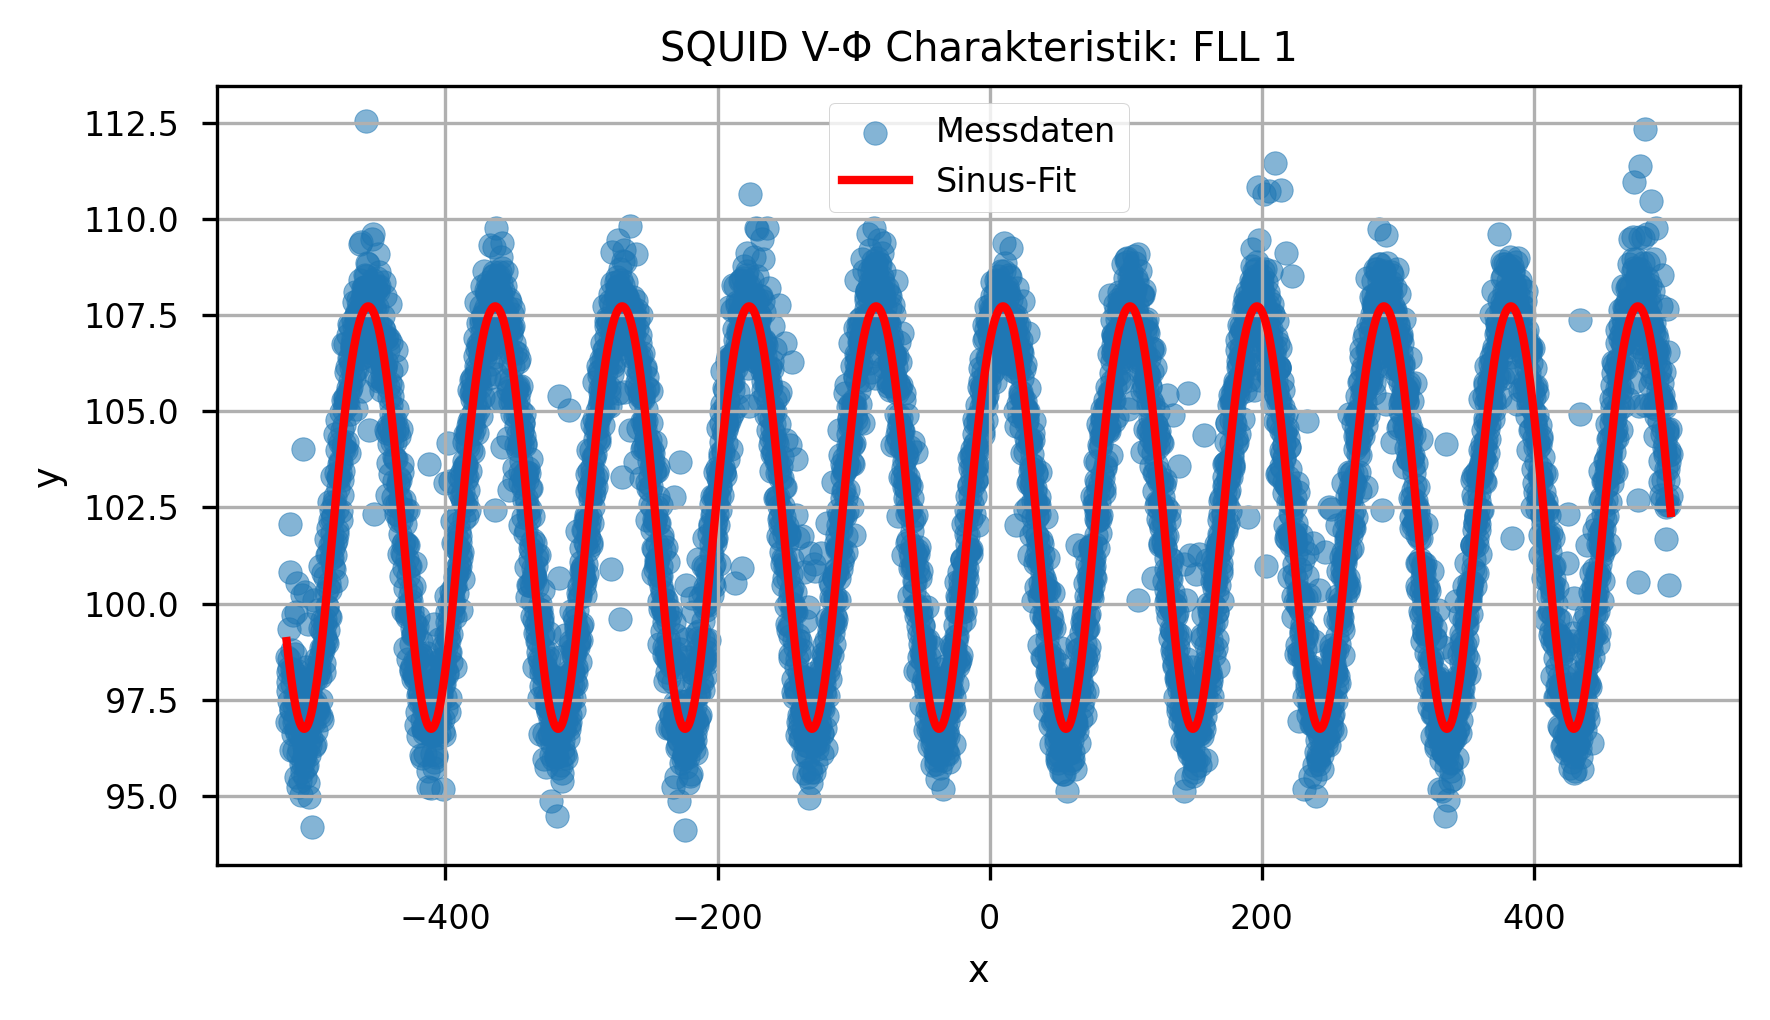


Fit für Internal flux 0 / Shapiro 4
A1:      5.5152 ± 0.0228224
f:       0.0107166 ± 2.27616e-06
phi1:    0.955301 ± 0.00416661
A2:      -0.243608 ± 0.0228459
phi2:    0.470588 ± 0.0943579
Offset:  102.411 ± 0.0161978
Periode: 93.3135


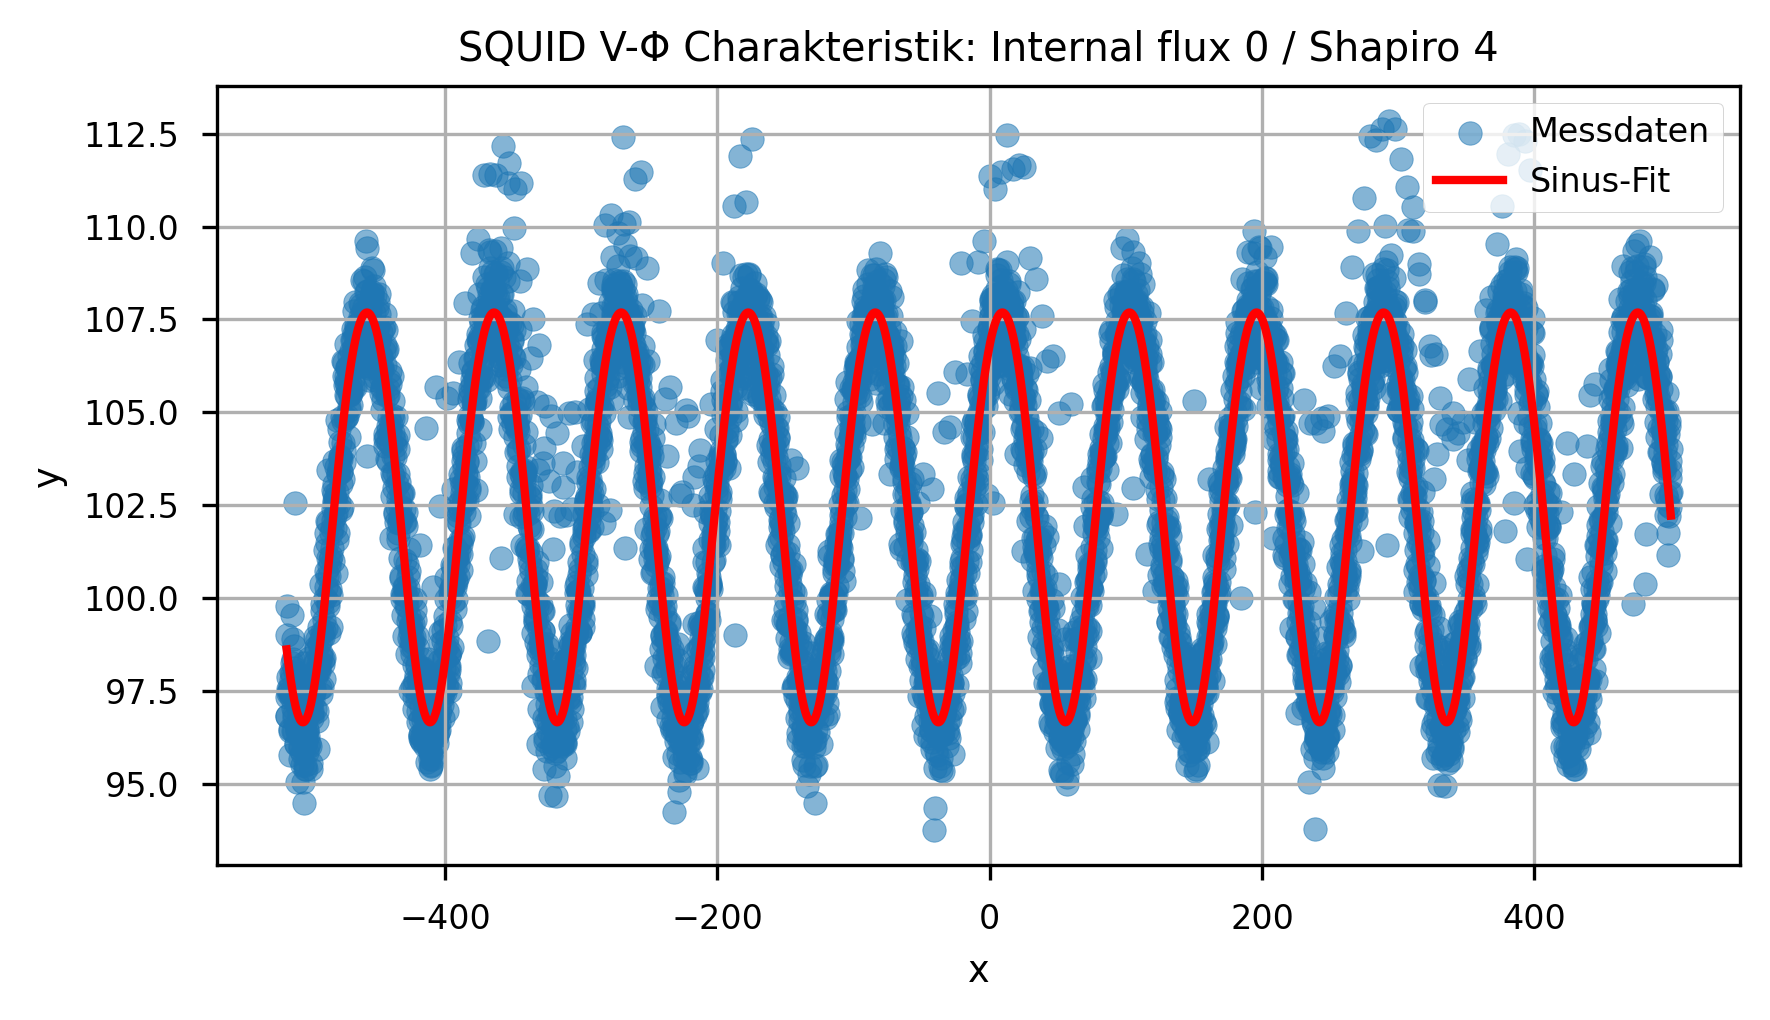

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
import matplotlib.style as mtlstyle

mtlstyle.use("seaborn-v0_8-paper")
rcParams["figure.dpi"] = 300
rcParams["figure.figsize"] = (6, 3.5)

def sine_function(x, A, f, phi, offset):
    return A * np.sin(2 * np.pi * f * x + phi) + offset

def sine_with_harmonic(x, A1, f, phi1, A2, phi2, offset):
    return (
        A1 * np.sin(2 * np.pi * f * x + phi1)
        + A2 * np.sin(4 * np.pi * f * x + phi2)
        + offset
    )

def read_csv_clean(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.replace('"', '').str.strip()
    df = df[["0_x", "0_y"]].dropna()
    df = df.sort_values("0_x")
    return df

def estimate_frequency_fft(x, y):
    x_uniform = np.linspace(x.min(), x.max(), len(x))
    y_uniform = np.interp(x_uniform, x, y)
    y_uniform = y_uniform - np.mean(y_uniform)

    dx = x_uniform[1] - x_uniform[0]
    freqs = np.fft.rfftfreq(len(x_uniform), d=dx)
    spectrum = np.abs(np.fft.rfft(y_uniform))

    freqs = freqs[1:]
    spectrum = spectrum[1:]

    return freqs[np.argmax(spectrum)]

def bin_data(x, y, n_bins=300):
    bins = np.linspace(x.min(), x.max(), n_bins + 1)
    inds = np.digitize(x, bins)

    xb, yb = [], []
    for i in range(1, len(bins)):
        mask = inds == i
        if np.sum(mask) > 2:
            xb.append(np.median(x[mask]))
            yb.append(np.median(y[mask]))

    return np.array(xb), np.array(yb)

def plot_and_fit(path, label, use_harmonic=True):
    df = read_csv_clean(path)

    x_raw = df["0_x"].to_numpy()
    y_raw = df["0_y"].to_numpy()

    x_fit, y_fit_data = bin_data(x_raw, y_raw, n_bins=350)

    # leichte Glättung nur für Frequenzschätzung
    window = min(51, len(y_fit_data) // 2 * 2 - 1)
    if window >= 7:
        y_for_fft = savgol_filter(y_fit_data, window, 3)
    else:
        y_for_fft = y_fit_data

    A_init = 0.5 * (np.percentile(y_fit_data, 95) - np.percentile(y_fit_data, 5))
    offset_init = np.median(y_fit_data)
    f_init = estimate_frequency_fft(x_fit, y_for_fft)

    if use_harmonic:
        fit_func = sine_with_harmonic
        p0 = [A_init, f_init, 0, 0.2 * A_init, 0, offset_init]
        bounds = (
            [-np.inf, 0.5 * f_init, -10*np.pi, -np.inf, -10*np.pi, -np.inf],
            [ np.inf, 1.5 * f_init,  10*np.pi,  np.inf,  10*np.pi,  np.inf],
        )
    else:
        fit_func = sine_function
        p0 = [A_init, f_init, 0, offset_init]
        bounds = (
            [-np.inf, 0.5 * f_init, -10*np.pi, -np.inf],
            [ np.inf, 1.5 * f_init,  10*np.pi,  np.inf],
        )

    popt, pcov = curve_fit(
        fit_func,
        x_fit,
        y_fit_data,
        p0=p0,
        bounds=bounds,
        maxfev=50000
    )

    perr = np.sqrt(np.diag(pcov))

    print("\n" + "="*70)
    print(f"Fit für {label}")
    print("="*70)

    if use_harmonic:
        A1, f, phi1, A2, phi2, offset = popt
        A1_err, f_err, phi1_err, A2_err, phi2_err, offset_err = perr

        print(f"A1:      {A1:.6g} ± {A1_err:.6g}")
        print(f"f:       {f:.6g} ± {f_err:.6g}")
        print(f"phi1:    {phi1:.6g} ± {phi1_err:.6g}")
        print(f"A2:      {A2:.6g} ± {A2_err:.6g}")
        print(f"phi2:    {phi2:.6g} ± {phi2_err:.6g}")
        print(f"Offset:  {offset:.6g} ± {offset_err:.6g}")
        print(f"Periode: {1/f:.6g}")
    else:
        A, f, phi, offset = popt
        A_err, f_err, phi_err, offset_err = perr

        print(f"A:       {A:.6g} ± {A_err:.6g}")
        print(f"f:       {f:.6g} ± {f_err:.6g}")
        print(f"phi:     {phi:.6g} ± {phi_err:.6g}")
        print(f"Offset:  {offset:.6g} ± {offset_err:.6g}")
        print(f"Periode: {1/f:.6g}")

    x_smooth = np.linspace(x_raw.min(), x_raw.max(), 2000)
    y_smooth = fit_func(x_smooth, *popt)

    plt.figure()

    # keine Scatterplots: Messdaten als Linie
    plt.scatter(x_raw, y_raw, label="Messdaten", alpha=0.55)

    # gebinnte Daten als glattere Hilfslinie
    #plt.plot(x_fit, y_fit_data, label="Gebinnte Messdaten", linewidth=1.2, color="orange")

    # Fit
    plt.plot(x_smooth, y_smooth, label="Sinus-Fit", linewidth=2.0, color="red")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"SQUID V-Φ Charakteristik: {label}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return popt, perr


files = [
    "10_26_2011-07_50_08_1s_biggest.csv",
    "10_26_2011-07_49_48_1s_biggest.csv",
    "10_26_2011-07_48_07_0_5s_biggest.csv",
    "10_26_2011-07_48_04_0_5s_biggest.csv",
    "10_26_2011-07_43_03_FLL_1.csv",
    "10_26_2011-07_42_14_Internal_flux_0_shapiro_stufen_4.csv",
]

labels = [
    "1s biggest 07:50:08",
    "1s biggest 07:49:48",
    "0.5s biggest 07:48:07",
    "0.5s biggest 07:48:04",
    "FLL 1",
    "Internal flux 0 / Shapiro 4",
]

results = {}

for path, label in zip(files, labels):
    try:
        results[label] = plot_and_fit(path, label, use_harmonic=True)
    except Exception as e:
        print(f"Fehler bei {label}: {e}")